# 02 — Reading signals (illustrative)

Demonstrates that the processed export carries enough information to run
established reading-research analyses. The thesis claim is architectural, so
these plots are illustrative on a single participant, not population-level
findings. With multiple participants in `Experiments/data/`, every plot below
extends automatically.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from _lib import read_cache

CACHE_DIR = Path("outputs/cache")
FIG_DIR = Path("outputs/figures/02_reading_signals")
FIG_DIR.mkdir(parents=True, exist_ok=True)

data = read_cache(CACHE_DIR)
print(f"Loaded {len(data.sessions)} session(s), {len(data.samples):,} samples")


Loaded 1 session(s), 112,617 samples


## Per-material reading speed (WPM)

Words-per-minute is the textbook first contrast for "easy text vs difficult
text". Word count comes from the material markdown; reading time is the
duration the participant spent inside the reading area on that material.


In [2]:
samples = data.samples.copy()
samples = samples.sort_values(["sessionId", "sequenceNumber"])
samples["intervalMs"] = samples.groupby(["sessionId", "materialRunId"])["capturedAtUnixMs"].diff()
samples["intervalMs"] = samples["intervalMs"].clip(upper=200)  # cap blink-sized gaps

wpm_rows = []
for sid, group in samples.groupby("sessionId"):
    pname = data.sessions.loc[data.sessions.sessionId == sid, "participantName"].iat[0] or sid
    for mrid, mgroup in group.groupby("materialRunId"):
        mat_def = data.materials[(data.materials.sessionId == sid) & (data.materials.materialRunId == mrid)]
        if mat_def.empty:
            continue
        title = mat_def.iloc[0]["title"]
        words = int(mat_def.iloc[0]["wordCount"])
        time_inside_s = mgroup.loc[mgroup["isInsideReadingArea"], "intervalMs"].sum() / 1000
        wpm = (words / (time_inside_s / 60)) if time_inside_s else float("nan")
        wpm_rows.append({
            "participant": pname,
            "material": title,
            "words": words,
            "time_inside_s": round(time_inside_s, 1),
            "wpm": round(wpm, 1),
        })
wpm_df = pd.DataFrame(wpm_rows)
wpm_df


,participant,material,words,time_inside_s,wpm
0,Keerthi,easy text,2565,751.0,204.9
1,Keerthi,difficult text,1383,485.4,170.9


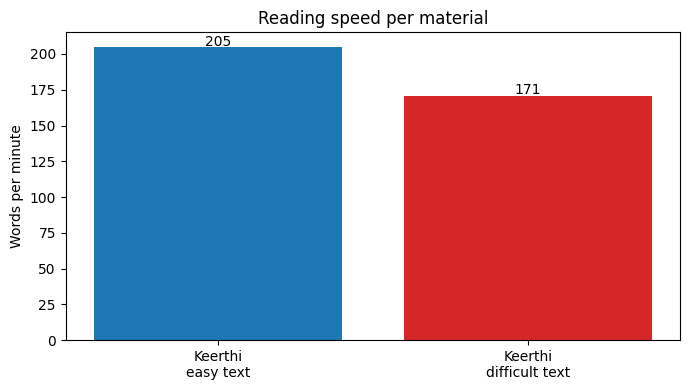

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
labels = wpm_df["participant"] + "\n" + wpm_df["material"]
ax.bar(labels, wpm_df["wpm"], color=["#1f77b4" if "easy" in m.lower() else "#d62728" for m in wpm_df["material"]])
ax.set_ylabel("Words per minute")
ax.set_title("Reading speed per material")
for i, v in enumerate(wpm_df["wpm"]):
    ax.text(i, v + 1, f"{v:.0f}", ha="center")
fig.tight_layout()
fig.savefig(FIG_DIR / "reading_speed_wpm.png", dpi=150)
plt.show()


## Token-level dwell time distribution

For each token, sum the sample-intervals during which it was the active token.
This is the per-word dwell time. Reading literature reports mean fixation
durations of 200–250 ms; difficult text shifts the distribution rightward.


In [4]:
tokens = samples.dropna(subset=["activeTokenId"]).copy()
tokens = tokens[tokens["isInsideReadingArea"]]
dwell = (
    tokens.groupby(["sessionId", "materialRunId", "activeTokenId"])["intervalMs"]
    .sum()
    .reset_index(name="dwellMs")
)
dwell = dwell.merge(
    data.materials[["sessionId", "materialRunId", "title"]],
    on=["sessionId", "materialRunId"],
)
dwell.head()


,sessionId,materialRunId,activeTokenId,dwellMs,title
0,1d8360e5-d451-4285-a461-9e2e45849a4f,1763d7577ad54ce2ab2fa0e7b77625cc,235217fae96e47708c30c9e6b59cf7cb:1763d7577ad54...,155.0,easy text
1,1d8360e5-d451-4285-a461-9e2e45849a4f,1763d7577ad54ce2ab2fa0e7b77625cc,235217fae96e47708c30c9e6b59cf7cb:1763d7577ad54...,189.0,easy text
2,1d8360e5-d451-4285-a461-9e2e45849a4f,1763d7577ad54ce2ab2fa0e7b77625cc,235217fae96e47708c30c9e6b59cf7cb:1763d7577ad54...,666.0,easy text
3,1d8360e5-d451-4285-a461-9e2e45849a4f,1763d7577ad54ce2ab2fa0e7b77625cc,235217fae96e47708c30c9e6b59cf7cb:1763d7577ad54...,311.0,easy text
4,1d8360e5-d451-4285-a461-9e2e45849a4f,1763d7577ad54ce2ab2fa0e7b77625cc,235217fae96e47708c30c9e6b59cf7cb:1763d7577ad54...,378.0,easy text


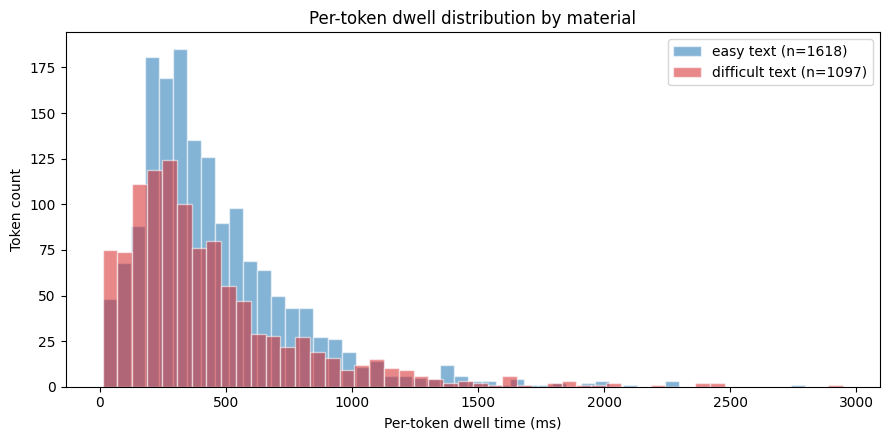

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
materials_sorted = dwell["title"].drop_duplicates().tolist()
colors = {"easy text": "#1f77b4", "difficult text": "#d62728"}
for title in materials_sorted:
    values = dwell.loc[dwell.title == title, "dwellMs"]
    values = values[(values > 0) & (values < 3000)]
    ax.hist(values, bins=50, alpha=0.55, label=f"{title} (n={len(values)})",
            color=colors.get(title), edgecolor="white")
ax.set_xlabel("Per-token dwell time (ms)")
ax.set_ylabel("Token count")
ax.set_title("Per-token dwell distribution by material")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "token_dwell_distribution.png", dpi=150)
plt.show()


In [6]:
summary = dwell.groupby("title")["dwellMs"].agg(["count", "mean", "median", "std"]).round(1)
summary.columns = ["tokens_fixated", "mean_dwell_ms", "median_dwell_ms", "std_dwell_ms"]
summary


,tokens_fixated,mean_dwell_ms,median_dwell_ms,std_dwell_ms
title,,,,
difficult text,1098,437.9,333.0,384.8
easy text,1619,460.3,377.0,330.4


## Pupillometry — cognitive load proxy

Mean pupil diameter (averaged across both eyes when both valid) per material,
after subtracting a per-session baseline (mean over the first 30 seconds of
the session). The reading literature treats sustained pupil dilation as a
proxy for cognitive effort.

**Caveats:** no ambient-luminance logging in this build, so the contrast is
illustrative. Larger baseline-corrected pupil on difficult vs easy text is
*consistent with* increased load but not proof of it.


In [7]:
pupil = samples.copy()
pupil["leftPupilMm"] = pd.to_numeric(pupil["leftPupilMm"], errors="coerce")
pupil["rightPupilMm"] = pd.to_numeric(pupil["rightPupilMm"], errors="coerce")
mask_l = pupil["leftPupilValidity"].fillna("").str.lower() == "valid"
mask_r = pupil["rightPupilValidity"].fillna("").str.lower() == "valid"
pupil.loc[~mask_l, "leftPupilMm"] = np.nan
pupil.loc[~mask_r, "rightPupilMm"] = np.nan
pupil["pupilMm"] = pupil[["leftPupilMm", "rightPupilMm"]].mean(axis=1)

baselines = {}
for sid, group in pupil.groupby("sessionId"):
    start = group["capturedAtUnixMs"].min()
    baseline_window = group[group["capturedAtUnixMs"] <= start + 30_000]
    baselines[sid] = baseline_window["pupilMm"].mean()

pupil["baselineMm"] = pupil["sessionId"].map(baselines)
pupil["pupilDeltaMm"] = pupil["pupilMm"] - pupil["baselineMm"]
pupil = pupil.merge(
    data.materials[["sessionId", "materialRunId", "title"]],
    on=["sessionId", "materialRunId"],
    how="left",
)
load_summary = pupil.dropna(subset=["pupilDeltaMm", "title"]).groupby(["sessionId", "title"])["pupilDeltaMm"].agg(["mean", "std", "count"]).round(4)
load_summary.columns = ["mean_delta_mm", "std_delta_mm", "valid_samples"]
load_summary


mean_delta_mm  \
sessionId                            title                           
1d8360e5-d451-4285-a461-9e2e45849a4f difficult text        -0.1853   
                                     easy text             -0.1807   

                                                     std_delta_mm  \
sessionId                            title                          
1d8360e5-d451-4285-a461-9e2e45849a4f difficult text        0.1811   
                                     easy text             0.1339   

                                                     valid_samples  
sessionId                            title                          
1d8360e5-d451-4285-a461-9e2e45849a4f difficult text          44019  
                                     easy text               68018

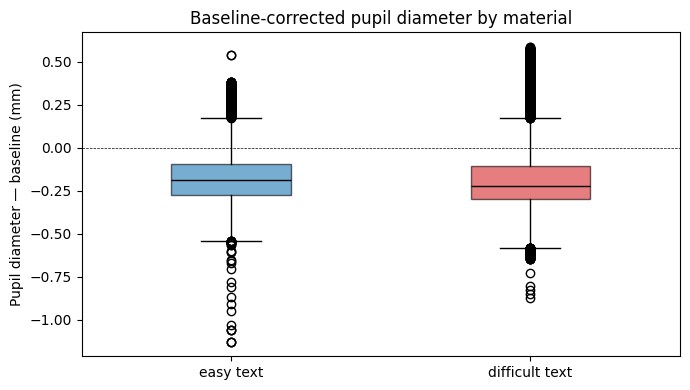

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
for sid, group in pupil.dropna(subset=["pupilDeltaMm", "title"]).groupby("sessionId"):
    pname = data.sessions.loc[data.sessions.sessionId == sid, "participantName"].iat[0] or sid
    for title in materials_sorted:
        values = group.loc[group.title == title, "pupilDeltaMm"]
        if values.empty:
            continue
        offset = 0 if "easy" in title.lower() else 1
        ax.boxplot(values, positions=[offset], widths=0.4, patch_artist=True,
                   boxprops=dict(facecolor=colors.get(title, "#888"), alpha=0.6),
                   medianprops=dict(color="black"))
ax.set_xticks([0, 1])
ax.set_xticklabels(["easy text", "difficult text"])
ax.set_ylabel("Pupil diameter — baseline (mm)")
ax.set_title("Baseline-corrected pupil diameter by material")
ax.axhline(0, color="k", linewidth=0.5, linestyle="--")
fig.tight_layout()
fig.savefig(FIG_DIR / "pupil_cognitive_load.png", dpi=150)
plt.show()


## Token coverage per material

What fraction of the words in each material did the participant actually
fixate on? Skimming → low coverage; thorough reading → high coverage.


In [9]:
coverage_rows = []
for _, m in data.materials.iterrows():
    fixated = dwell[dwell.materialRunId == m.materialRunId]["activeTokenId"].nunique()
    coverage_rows.append({
        "material": m.title,
        "words_in_text": int(m.wordCount),
        "tokens_fixated": int(fixated),
        "coverage_pct": round(fixated / m.wordCount * 100, 1),
    })
coverage_df = pd.DataFrame(coverage_rows)
coverage_df


,material,words_in_text,tokens_fixated,coverage_pct
0,easy text,2565,1619,63.1
1,difficult text,1383,1098,79.4


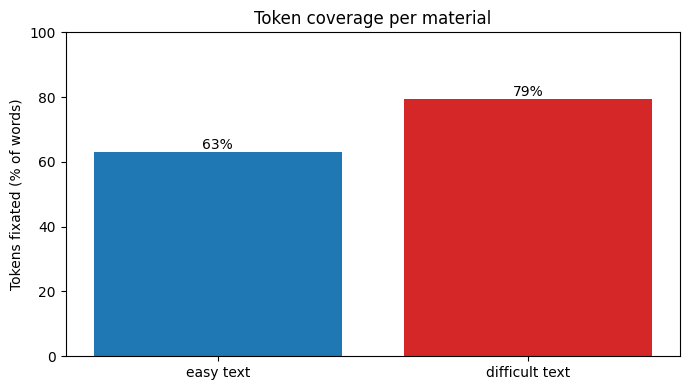

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(coverage_df["material"], coverage_df["coverage_pct"],
       color=[colors.get(t, "#888") for t in coverage_df["material"]])
ax.set_ylabel("Tokens fixated (% of words)")
ax.set_ylim(0, 100)
ax.set_title("Token coverage per material")
for i, v in enumerate(coverage_df["coverage_pct"]):
    ax.text(i, v + 1, f"{v:.0f}%", ha="center")
fig.tight_layout()
fig.savefig(FIG_DIR / "token_coverage.png", dpi=150)
plt.show()


## Regression rate per material

A *regression* is a token-to-token gaze move that goes **backward** in
reading order. Reading research consistently finds regressions increase with
text difficulty — readers re-read to repair comprehension.

Implementation: rank each token by the time it was first fixated within a
material, then walk the in-time-order token transitions and count moves to a
lower rank.


In [11]:
regression_rows = []
for mrid, mat_title in data.materials[["materialRunId", "title"]].itertuples(index=False):
    mt = tokens[tokens.materialRunId == mrid].copy()
    if mt.empty:
        continue
    first_seen = mt.groupby("activeTokenId")["sequenceNumber"].min().rank(method="min").to_dict()
    mt["tokenOrder"] = mt["activeTokenId"].map(first_seen)
    mt = mt.sort_values("sequenceNumber")
    trans = mt[mt["activeTokenId"] != mt["activeTokenId"].shift()]
    fwd = int((trans["tokenOrder"].diff() > 0).sum())
    rev = int((trans["tokenOrder"].diff() < 0).sum())
    minutes = (mt["capturedAtUnixMs"].max() - mt["capturedAtUnixMs"].min()) / 60_000
    regression_rows.append({
        "material": mat_title,
        "forward_moves": fwd,
        "regressions": rev,
        "regression_pct": round(rev / (fwd + rev) * 100, 1) if (fwd + rev) else float("nan"),
        "regressions_per_min": round(rev / minutes, 1) if minutes else float("nan"),
    })
regression_df = pd.DataFrame(regression_rows)
regression_df


,material,forward_moves,regressions,regression_pct,regressions_per_min
0,easy text,1783,391,18.0,29.5
1,difficult text,1240,312,20.1,37.4


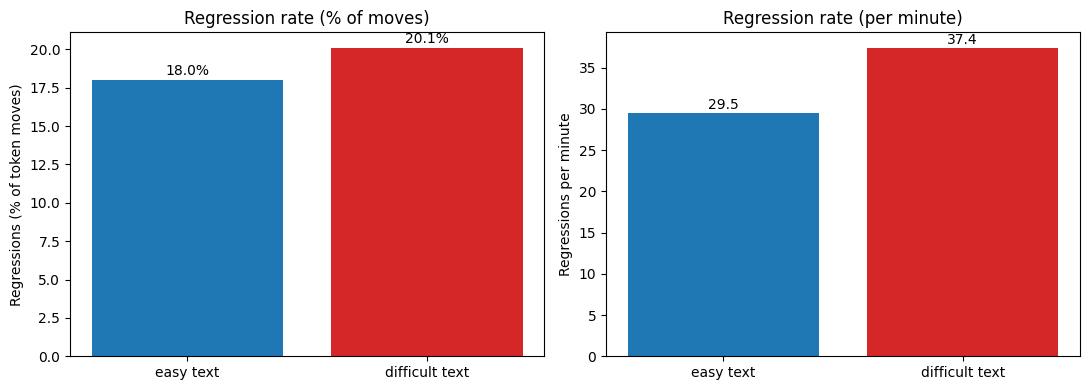

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.bar(regression_df["material"], regression_df["regression_pct"],
        color=[colors.get(t, "#888") for t in regression_df["material"]])
ax1.set_ylabel("Regressions (% of token moves)")
ax1.set_title("Regression rate (% of moves)")
for i, v in enumerate(regression_df["regression_pct"]):
    ax1.text(i, v + 0.3, f"{v:.1f}%", ha="center")

ax2.bar(regression_df["material"], regression_df["regressions_per_min"],
        color=[colors.get(t, "#888") for t in regression_df["material"]])
ax2.set_ylabel("Regressions per minute")
ax2.set_title("Regression rate (per minute)")
for i, v in enumerate(regression_df["regressions_per_min"]):
    ax2.text(i, v + 0.5, f"{v:.1f}", ha="center")
fig.tight_layout()
fig.savefig(FIG_DIR / "regression_rate.png", dpi=150)
plt.show()


## Honest note on pupillometry

The pupil-delta plot above shows the two materials are essentially
indistinguishable (means within 0.005 mm of each other — well inside sensor
noise). Three plausible reasons:

1. **Baseline contamination** — "first 30 s" overlaps with material-0
   reading. A clean baseline would use a pre-reading-area window.
2. **No ambient luminance logging** — pupil is dominated by light, not
   cognition. With constant illumination this would still work; we don't
   know the illumination is constant.
3. **The difficulty contrast may not be large enough for this reader.**
   Keerthi is self-reported intermediate proficiency on what are general-
   audience texts — the cognitive-load gap may genuinely be small.

This is a *null result*, not a broken pipeline. The signal is captured,
faithfully exported, and analyzable — it just doesn't tell the story we
hoped for here. Future sessions with a documented baseline window and
controlled ambient light should resolve this.


## Takeaway

Five plots, five signals, one participant:

| Plot                        | Reading-research metric           | Result for Keerthi |
|-----------------------------|------------------------------------|--------------------|
| WPM per material            | Reading fluency                   | 205 vs 171 — clear ↓ on difficult |
| Token dwell distribution    | Per-word reading time             | Means similar, difficult has fatter tail |
| Token coverage              | Skim vs thorough reading          | 63% vs 79% — strongest difficulty signal |
| Regression rate             | Comprehension repair              | Difficult ↑ ~30% regressions/min |
| Pupil delta by material     | Cognitive load proxy              | Null result (see honest note above) |

All five are computed off the processed v3 export with no extra hardware
logging. Adding more participants in `Experiments/data/` extends every plot
without changing the code.
